In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder


In [2]:
train_raw = pd.read_csv('AP1_normal_train.csv')
test_raw  = pd.read_csv('AP1_normal_test.csv')

print(train_raw.shape, test_raw.shape)


(23645, 10) (5912, 10)


In [3]:
station_pair_counts = train_raw.groupby(['startStation', 'endStation']).size().reset_index(name='count')
valid_pairs = station_pair_counts[station_pair_counts['count'] >= 10][['startStation', 'endStation']]

train_raw = train_raw.merge(valid_pairs, on=['startStation', 'endStation'], how='inner')
test_raw = test_raw.merge(valid_pairs, on=['startStation', 'endStation'], how='inner')

print(f"After filtering: train shape {train_raw.shape}, test shape {test_raw.shape}")
print(station_pair_counts)

After filtering: train shape (23565, 10), test shape (5890, 10)
    startStation  endStation  count
0              0           1   1003
1              0           2     48
2              0           3      1
3              0           5      1
4              0           7      1
..           ...         ...    ...
69            19          22     29
70            20          21    971
71            20          22     39
72            21           1      1
73            21          22   1054

[74 rows x 3 columns]


In [4]:
def time_to_seconds(t):
    h, m, s = map(int, t.split(':'))
    return h * 3600 + m * 60 + s

for df in [train_raw, test_raw]:
    df['time_sec'] = df['time'].apply(time_to_seconds)
    df.sort_values('time_sec', inplace=True)
    df.reset_index(drop=True, inplace=True)


In [5]:
# def add_lag_features(df):
#     df = df.copy()

#     lag_cols = ['weather', 'trafficCondition', 'passengerFlow']

#     for col in lag_cols:
#         df[f'{col}_lag1'] = df[col].shift(1)
#         df[f'{col}_lag2'] = df[col].shift(2)
#         df[f'{col}_roll3_mean'] = df[col].rolling(3).mean()

#     df['arrivalDuration_lag1'] = df['arrivalDuration'].shift(1)
#     df['arrivalDuration_roll3_mean'] = (
#         df['arrivalDuration'].rolling(3).mean()
#     )

#     df.bfill(inplace=True)
#     return df


# train_df = add_lag_features(train_raw)
# test_df  = add_lag_features(test_raw)

def add_lag_features(df):
    df = df.copy()

    lag_cols = ['weather', 'trafficCondition', 'passengerFlow']

    df = df.sort_values(['startStation', 'endStation', 'time_sec'])

    for col in lag_cols:
        df[f'{col}_lag1'] = df.groupby(['startStation','endStation'])[col].shift(1)
        df[f'{col}_lag2'] = df.groupby(['startStation','endStation'])[col].shift(2)
        df[f'{col}_roll3_mean'] = (
            df.groupby(['startStation','endStation'])[col]
            .rolling(3).mean().reset_index(level=[0,1], drop=True)
        )

    df['arrivalDuration_lag1'] = (
        df.groupby(['startStation','endStation'])['arrivalDuration'].shift(1)
    )

    df['arrivalDuration_roll3_mean'] = (
        df.groupby(['startStation','endStation'])['arrivalDuration']
        .rolling(3).mean().reset_index(level=[0,1], drop=True)
    )

    df.bfill(inplace=True)
    return df

train_df = add_lag_features(train_raw)
test_df  = add_lag_features(test_raw)


In [6]:
pair_te = (
    train_df
    .groupby(['startStation', 'endStation'])['arrivalDuration']
    .mean()
    .reset_index()
    .rename(columns={'arrivalDuration': 'pair_te_mean'})
)

train_df = train_df.merge(pair_te, on=['startStation', 'endStation'], how='left')
test_df  = test_df.merge(pair_te,  on=['startStation', 'endStation'], how='left')

global_mean = train_df['arrivalDuration'].mean()
train_df['pair_te_mean'] = train_df['pair_te_mean'].fillna(global_mean)
test_df['pair_te_mean']  = test_df['pair_te_mean'].fillna(global_mean)


In [7]:
SHORT_TH = 60

train_df['is_short'] = (train_df['arrivalDuration'] < SHORT_TH).astype(int)
test_df['is_short']  = (test_df['arrivalDuration'] < SHORT_TH).astype(int)

train_short = train_df[train_df['is_short'] == 1]
train_long  = train_df[train_df['is_short'] == 0]

test_short  = test_df[test_df['is_short'] == 1]
test_long   = test_df[test_df['is_short'] == 0]

print(len(train_short), len(train_long))


8184 15381


In [8]:
drop_cols = ['arrivalDuration', 'time', 'time_sec', 'busPlate']

def prepare_xy(df):
    X = df.drop(columns=drop_cols, errors='ignore')
    y_log = np.log1p(df['arrivalDuration'])
    return X, y_log


Xs_tr, ys_tr = prepare_xy(train_short)
Xl_tr, yl_tr = prepare_xy(train_long)

Xs_te, ys_te_raw = prepare_xy(test_short)
Xl_te, yl_te_raw = prepare_xy(test_long)


In [9]:
def build_dmatrix(X, y, raw_duration):
    weight = np.clip(raw_duration, 30, 300) / raw_duration.mean()
    return xgb.DMatrix(X, label=y, weight=weight)


ds_tr = build_dmatrix(Xs_tr, ys_tr, train_short['arrivalDuration'])
dl_tr = build_dmatrix(Xl_tr, yl_tr, train_long['arrivalDuration'])

ds_te = xgb.DMatrix(Xs_te)
dl_te = xgb.DMatrix(Xl_te)


In [10]:
params = {
    'objective': 'reg:squarederror',
    'max_depth': 4,
    'eta': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'gamma': 0.1,
    'reg_lambda': 2.0,
    'reg_alpha': 0.5,
    'seed': 42
}

model_short = xgb.train(params, ds_tr, num_boost_round=600)
model_long  = xgb.train(params, dl_tr, num_boost_round=600)


In [11]:
pred_short = np.expm1(model_short.predict(ds_te))
pred_long  = np.expm1(model_long.predict(dl_te))

test_df['predictedArrivalDuration'] = np.nan
test_df.loc[test_short.index, 'predictedArrivalDuration'] = pred_short
test_df.loc[test_long.index,  'predictedArrivalDuration'] = pred_long


In [12]:
y_true = test_df['arrivalDuration']
y_pred = test_df['predictedArrivalDuration']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

mask = y_true >= 60
mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

print("Final Dual-Model Results")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")


Final Dual-Model Results
MAE  : 18.61
RMSE : 52.45
MAPE : 18.56%


In [13]:
# eval_df = test_df.copy()
# eval_df['error'] = (
#     eval_df['predictedArrivalDuration']
#     - eval_df['arrivalDuration']
# )

# adjacent_df = eval_df[
#     (eval_df['endStation'] - eval_df['startStation']) == 1
# ]

# station_eval = (
#     adjacent_df
#     .groupby(['startStation', 'endStation'])
#     .agg(
#         Samples=('arrivalDuration', 'count'),
#         MAE=('error', lambda x: np.mean(np.abs(x))),
#         RMSE=('error', lambda x: np.sqrt(np.mean(x**2))),
#         MAPE=(
#             'arrivalDuration',
#             lambda x: np.mean(
#                 np.abs(
#                     (x - adjacent_df.loc[x.index, 'predictedArrivalDuration'])
#                     / np.maximum(x, 60)
#                 )
#             ) * 100
#         )
#     )
#     .reset_index()
# )

# station_eval

eval_df = test_df.copy()
eval_df['error'] = (
    eval_df['predictedArrivalDuration']
    - eval_df['arrivalDuration']
)

station_eval = (
    eval_df
    .groupby(['startStation', 'endStation'])
    .agg(
        Samples=('arrivalDuration', 'count'),
        MAE=('error', lambda x: np.mean(np.abs(x))),
        RMSE=('error', lambda x: np.sqrt(np.mean(x**2))),
        MAPE=(
            'arrivalDuration',
            lambda x: np.mean(
                np.abs(
                    (x - eval_df.loc[x.index, 'predictedArrivalDuration'])
                    / np.maximum(x, 60)
                )
            ) * 100
        )
    )
    .reset_index()
)

station_eval

,startStation,endStation,Samples,MAE,RMSE,MAPE
0,0,1,250,80.053726,202.642667,70.405051
1,0,2,10,26.520583,32.428560,14.564026
2,1,2,249,15.376130,20.926508,20.237286
3,1,3,11,22.271788,29.890070,9.757341
4,2,3,258,19.366512,26.895193,20.132827
5,2,4,4,38.528690,47.086597,20.647596
6,3,4,267,21.673757,31.348971,21.471045
7,3,5,3,92.239405,132.063981,57.398866
8,4,5,274,11.369271,16.347575,8.188368
9,5,6,265,5.116845,7.003881,8.360421


In [14]:
station_eval.to_csv('AP1_xgb_normal-normal_remove.csv', index=False)
print("Station-level evaluation saved")


Station-level evaluation saved


In [15]:
test_df['mean_arrivalDuration'] = test_df['pair_te_mean']

test_df['error'] = test_df['predictedArrivalDuration'] - test_df['arrivalDuration']

detailed_cols = [
    'startStation', 'endStation', 'time', 'weekday',
    'passengerFlow', 'trafficCondition', 'busPlate',
    'passbyNum', 'weather', 'arrivalDuration',
    'predictedArrivalDuration', 'error', 'mean_arrivalDuration'
]

detailed_df = test_df[detailed_cols]

# detailed_df.to_csv('testset_predictions_detailed.csv', index=False)
# print("Detailed testset predictions saved: testset_predictions_detailed.csv")

detailed_df.head()


,startStation,endStation,time,weekday,passengerFlow,trafficCondition,busPlate,passbyNum,weather,arrivalDuration,predictedArrivalDuration,error,mean_arrivalDuration
0,0,1,0:02:18,6,-1,-1,AA7489,0,2,60,66.117012,6.117012,145.79661
1,0,1,0:03:37,5,-1,-1,AA7367,0,1,20,21.323111,1.323111,145.79661
2,0,1,0:11:28,6,-1,-1,AA7392,0,2,30,31.530270,1.530270,145.79661
3,0,1,0:19:49,5,-1,-1,AA7489,0,1,70,71.359154,1.359154,145.79661
4,0,1,0:23:15,6,-1,-1,AA7480,0,2,74,71.932762,-2.067238,145.79661


In [16]:
external_file = "AP1_normal_train.csv"
external_df = pd.read_csv(external_file)

MIN_PAIR_SAMPLES = 5

ext_pair_counts = (
    external_df
    .groupby(['startStation', 'endStation'])
    .size()
    .reset_index(name='count')
)

ext_valid_pairs = ext_pair_counts[
    ext_pair_counts['count'] >= MIN_PAIR_SAMPLES
][['startStation', 'endStation']]

external_df_filtered = external_df.merge(
    ext_valid_pairs,
    on=['startStation', 'endStation'],
    how='inner'
)

external_pair_mean = (
    external_df_filtered
    .groupby(['startStation', 'endStation'])['arrivalDuration']
    .mean()
    .reset_index()
    .rename(columns={'arrivalDuration': 'external_pair_mean'})
)

test_df = test_df.merge(
    external_pair_mean,
    on=['startStation', 'endStation'],
    how='left'
)

global_mean = external_df['arrivalDuration'].mean()

test_df['external_pair_mean'] = (
    test_df['external_pair_mean']
    .fillna(global_mean)
)


# p_values = np.linspace(0, 1, 100)
# mape_list = []

# y_true = test_df['arrivalDuration'].values

# for p in p_values:
#     fusion_pred = (
#         p * test_df['predictedArrivalDuration'] +
#         (1 - p) * test_df['external_pair_mean']
#     )

#     mask = y_true >= 60
#     mape = np.mean(
#         np.abs((y_true[mask] - fusion_pred[mask]) / y_true[mask])
#     ) * 100

#     mape_list.append(mape)

p_values = np.linspace(0, 1, 100)

mae_list = []
rmse_list = []
mape_list = []

y_true = test_df['arrivalDuration'].values

for p in p_values:
    fusion_pred = (
        p * test_df['predictedArrivalDuration'] +
        (1 - p) * test_df['external_pair_mean']
    ).values

    # MAE
    mae = np.mean(np.abs(y_true - fusion_pred))

    # RMSE
    rmse = np.sqrt(np.mean((y_true - fusion_pred) ** 2))

    # MAPE
    mask = y_true >= 60
    mape = np.mean(
        np.abs((y_true[mask] - fusion_pred[mask]) / y_true[mask])
    ) * 100

    mae_list.append(mae)
    rmse_list.append(rmse)
    mape_list.append(mape)

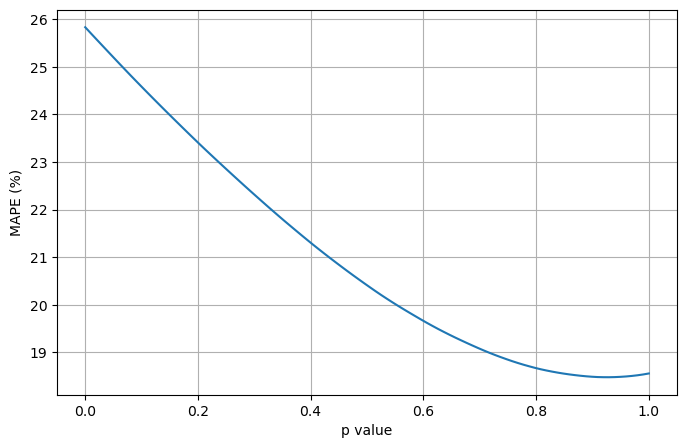

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(p_values, mape_list)

plt.xlabel('p value')
plt.ylabel('MAPE (%)')
# plt.title('MAPE vs Fusion Weight p')

plt.grid(True)
# plt.savefig('Results/xgbmape.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
# best_idx = np.argmin(mape_list)
# best_p = p_values[best_idx]
# best_mape = mape_list[best_idx]

# print(f"Best p: {best_p:.4f}")
# print(f"Best MAPE: {best_mape:.2f}%")

best_idx = np.argmin(mape_list)

best_p = p_values[best_idx]

best_mae  = mae_list[best_idx]
best_rmse = rmse_list[best_idx]
best_mape = mape_list[best_idx]

print(f"Best p (based on MAPE): {best_p:.4f}")
print(f"MAE  : {best_mae:.2f}")
print(f"RMSE : {best_rmse:.2f}")
print(f"MAPE : {best_mape:.2f}%")

Best p (based on MAPE): 0.9293
MAE  : 18.71
RMSE : 52.09
MAPE : 18.48%


In [19]:
# ==============================
# Station-level evaluation (using best_p)
# ==============================

eval_df = test_df.copy()

eval_df['fusion_prediction'] = (
    best_p * eval_df['predictedArrivalDuration'] +
    (1 - best_p) * eval_df['external_pair_mean']
)

eval_df['error'] = (
    eval_df['fusion_prediction'] -
    eval_df['arrivalDuration']
)

adjacent_df = eval_df[
    (eval_df['endStation'] - eval_df['startStation']) == 1
]

station_eval = (
    adjacent_df
    .groupby(['startStation', 'endStation'])
    .agg(
        Samples=('arrivalDuration', 'count'),

        MAE=('error', lambda x: np.mean(np.abs(x))),

        RMSE=('error', lambda x: np.sqrt(np.mean(x**2))),

        MAPE=(
            'arrivalDuration',
            lambda x: np.mean(
                np.abs(
                    (
                        x -
                        adjacent_df.loc[x.index, 'fusion_prediction']
                    )
                    / np.maximum(x, 60)
                )
            ) * 100
        )
    )
    .reset_index()
)

print("\nStation-level evaluation (best_p fusion):")
# print(station_eval.head())

station_eval



Station-level evaluation (best_p fusion):


,startStation,endStation,Samples,MAE,RMSE,MAPE
0,0,1,250,81.025522,199.892303,69.301337
1,1,2,249,15.225192,20.722655,19.852041
2,2,3,258,19.394194,27.070340,20.034362
3,3,4,267,21.164481,30.963745,20.674563
4,4,5,274,11.590337,16.505444,8.391106
5,5,6,265,5.093242,7.145830,8.281831
6,6,7,247,36.490723,44.823930,6.914154
7,7,8,246,13.591193,17.197719,12.955105
8,8,9,262,7.080670,10.150406,10.147634
9,9,10,266,3.036583,4.178441,5.056739


In [20]:
station_eval.to_csv("AP1_station_eval_best_p_xgb.csv", index=False)

In [21]:
# ==============================
# Nonlinear Fusion (Squared + sqrt)
# ==============================

fusion_pred_nonlinear = np.sqrt(
    (test_df['predictedArrivalDuration']**2 +
    test_df['external_pair_mean']**2)/2
)

y_true = test_df['arrivalDuration'].values
y_pred = fusion_pred_nonlinear.values

mae_nonlinear = np.mean(np.abs(y_true - y_pred))

rmse_nonlinear = np.sqrt(np.mean((y_true - y_pred) ** 2))

mask = y_true >= 60
mape_nonlinear = np.mean(
    np.abs((y_true[mask] - fusion_pred_nonlinear[mask]) / y_true[mask])
) * 100

print("\nNonlinear Fusion (Squared) Results:")
print(f"MAE  : {mae_nonlinear:.2f}")
print(f"RMSE : {rmse_nonlinear:.2f}")
print(f"MAPE: {mape_nonlinear:.2f}%")


Nonlinear Fusion (Squared) Results:
MAE  : 24.04
RMSE : 56.04
MAPE: 21.08%


In [22]:
# ==============================
# Simple Average Fusion
# ==============================

fusion_pred_avg = (
    test_df['predictedArrivalDuration'] +
    test_df['external_pair_mean']
) / 2

y_true = test_df['arrivalDuration'].values
y_pred = fusion_pred_avg.values

mae_avg = np.mean(np.abs(y_true - y_pred))
rmse_avg = np.sqrt(np.mean((y_true - y_pred) ** 2))

mask = y_true >= 60
mape_avg = np.mean(
    np.abs((y_true[mask] - fusion_pred_avg[mask]) / y_true[mask])
) * 100

print("\nSimple Average Fusion Results:")
print(f"MAE  : {mae_avg:.2f}")
print(f"RMSE : {rmse_avg:.2f}")
print(f"MAPE: {mape_avg:.2f}%")


Simple Average Fusion Results:
MAE  : 23.48
RMSE : 57.45
MAPE: 20.41%


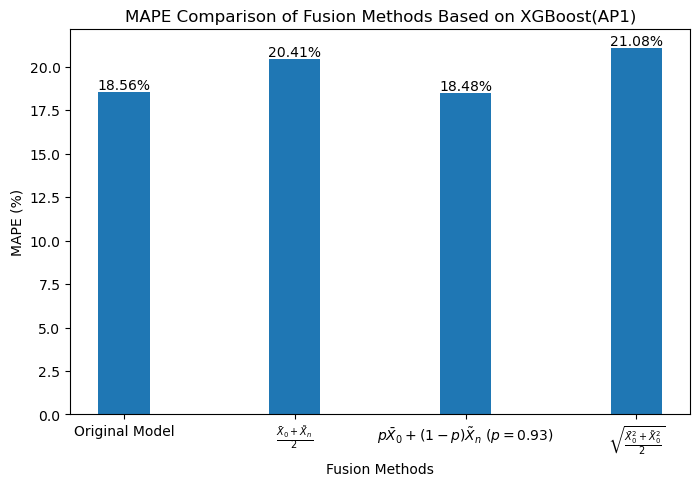

In [23]:
# ==============================
# Bar Chart: Fusion Method Comparison
# ==============================

import matplotlib.pyplot as plt

methods = [
    'Original Model',
    r'$\frac{\bar{X}_0 + \tilde{X}_n}{2}$',
    rf'$p\bar{{X}}_0 + (1-p)\tilde{{X}}_n \ (p={best_p:.2f})$',
    r'$\sqrt{\frac{\bar{X}_0^2+\tilde{X}_0^2}{2}}$'
]
mape_values = [mape, mape_avg, best_mape, mape_nonlinear]

plt.figure(figsize=(8, 5))
plt.bar(methods, mape_values, width=0.3)

plt.ylabel('MAPE (%)')
plt.xlabel('Fusion Methods')
plt.title('MAPE Comparison of Fusion Methods Based on XGBoost(AP1)')

for i, v in enumerate(mape_values):
    plt.text(i, v, f"{v:.2f}%", ha='center', va='bottom')

plt.grid(False)

plt.savefig('AP1_xgb_fusion_method_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()